# Principal Component Analysis implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **pandas** for tabular data handling, **numpy** for the vectorized math behind the model, **matplotlib** for visualization, and **load_breast_cancer** from scikit-learn as a real-data source.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

### Loading Data

Loads the real Breast Cancer Wisconsin dataset using all 569 real patients with all 30 real tumor measurements as features.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

X = df.drop(columns=["target"]).values.astype(float)
y = np.array(["malignant" if t == 0 else "benign" for t in df["target"].values])

print(f"Examples: {X.shape[0]}, Features: {X.shape[1]}")

Examples: 569, Features: 30


### Standardizing Features

Scales all 30 features to the same standardized range before computing anything.

In [3]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

### PCA Class

Implements PCA from scratch: computes the covariance matrix of the centered data, finds its eigenvectors and eigenvalues via **np.linalg.eigh**, sorts them by eigenvalue, and keeps the top **n_components** as the directions capturing the most real variance in the data. **transform** projects new data onto those directions; **fit_transform** does both in sequence.


In [4]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean = X.mean(axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # eigh returns eigenvalues in ascending order — flip to descending
        # so the components explaining the most variance come first
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance = eigenvalues[:self.n_components]
        self.explained_variance_ratio = eigenvalues[:self.n_components] / np.sum(eigenvalues)

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

### Applying PCA

Fits PCA with **n_components=2** on the real standardized data and reports how much of the total variance those two components capture.

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio}")
print(f"Total variance retained by 2 components: {pca.explained_variance_ratio.sum()*100:.2f}%")

Explained variance ratio: [0.44272026 0.18971182]
Total variance retained by 2 components: 63.24%


PC1 captures **44.27%** of total variance, PC2 captures **18.97%**. Together, **63.24%** of everything happening across all 30 real features is preserved in just 2 numbers per patient.

### Visualizing the Principal Components

Plots every patient's 2 principal component values, colored by their real diagnosis.

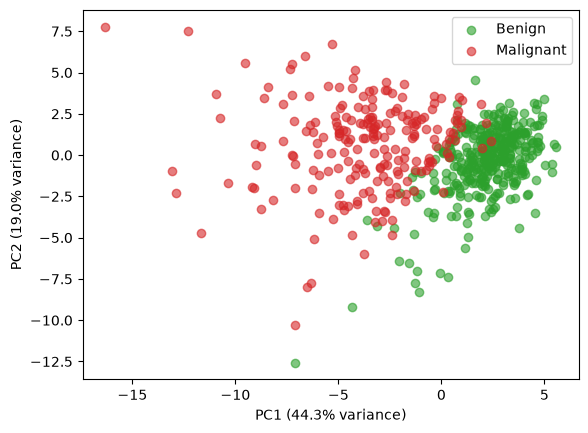

In [6]:
plt.scatter(X_pca[y == 'benign', 0], X_pca[y == 'benign', 1], color='tab:green', label='Benign', alpha=0.6)
plt.scatter(X_pca[y == 'malignant', 0], X_pca[y == 'malignant', 1], color='tab:red', label='Malignant', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio[1]*100:.1f}% variance)')
plt.legend()
plt.show()

Visible separation between malignant and benign patients emerges in this plot.

### Sklearn Validation

Fits scikit-learn's **PCA** with the same **n_components=2** on the identical standardized data, as an independent correctness check.

In [7]:
from sklearn.decomposition import PCA as SkPCA

sk_pca = SkPCA(n_components=2)
X_sk_pca = sk_pca.fit_transform(X_scaled)

print(f"From scratch explained variance ratio: {pca.explained_variance_ratio}")
print(f"sklearn explained variance ratio:      {sk_pca.explained_variance_ratio_}")

From scratch explained variance ratio: [0.44272026 0.18971182]
sklearn explained variance ratio:      [0.44272026 0.18971182]


Exact match: [0.4427, 0.1897] for both.